# Pattern Correlation between Factual and ERA5

Import statements

In [2]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray
import xarray as xr
from scipy import stats

## Open/process data

In [3]:
years = np.arange(2004, 2023 + 1, 1)

namelist_f = [
    f"/glade/derecho/scratch/smhenry/neuralGCM/sims/factual/ensmean_monthly/{yr}_ensmean_monthly_factual_raw.nc"
    for yr in years
]

namelist_era5 = [
    f"/glade/derecho/scratch/smhenry/neuralGCM/Data/ERA5/ERA5_forcing_{yr}_JASO.nc"
    for yr in years
]

Concatenate and save monthly mean data

In [4]:
# factual_mean = xr.concat([xr.open_dataset(namelist_f[yr]) for yr in range(len(years))], dim="time")
# factual_mean.to_netcdf("/glade/derecho/scratch/smhenry/neuralGCM/sims/factual_actual/ensmean_monthly/2004-2023_ensmean_monthly_factual_raw.nc")
factual_mean = xr.open_dataset(
    "/glade/derecho/scratch/smhenry/neuralGCM/sims/factual/ensmean_monthly/2004-2023_ensmean_monthly_factual_raw.nc"
)

In [5]:
# era5_mean = xr.concat([xr.open_dataset(namelist_era5[yr])[["geopotential","u_component_of_wind"]].resample(time="1ME").mean() for yr in range(len(years))], dim="time")
# era5_mean.to_netcdf("/glade/derecho/scratch/smhenry/neuralGCM/Data/ERA5/ERA5_forcing_2004-2023_monthly_GPH_U.nc")
era5_mean = xr.open_dataset(
    "/glade/derecho/scratch/smhenry/neuralGCM/Data/ERA5/ERA5_forcing_2004-2023_monthly_GPH_U.nc"
)

## Pattern correlation function

In [6]:
def get_pattern_corr(data_f_mo, data_era5_mo):
    """
    calculates the pattern correlation between two datasets
    input:
        data_f_mo: factual simulation data for one month
        data_era5_mo: ERA5 data for one month
    output:
        corr
    """
    data_f_flat = data_f_mo.values.flatten()
    data_era5_flat = data_era5_mo.values.flatten()
    
    valid_mask = ~np.isnan(data_f_flat) & ~np.isnan(data_era5_flat)
    r, _ = stats.pearsonr(data_f_flat[valid_mask], data_era5_flat[valid_mask])
    corr = r

    return corr


def plot_pattern_corr(data_f, data_era5, title=None, save=None, savename=None, ylim=None, color=None):
    """
    plots time series of monthly pattern correlations between two datasets
    input:
        data_f: factual simulation data
        data_era5: ERA5 data
    output:
        None, returns a plot
    """
    times = data_f.time.values
    pattern_corrs = []

    for time in times:
        data_f_mo = data_f.sel(time=time)
        data_era5_mo = data_era5.sel(time=time)

        corr = get_pattern_corr(data_f_mo, data_era5_mo)
        pattern_corrs.append(corr)

    plt.figure(figsize=(8, 4))
    plt.plot(times, pattern_corrs, marker='o', linestyle='-', color=color)
    plt.xlabel('Time')
    plt.ylabel('Pattern Correlation')
    # if ylim:
    plt.ylim(ylim)
    if title:
        plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    if save:
        plt.savefig(f"./figs/{savename}")
    plt.show()

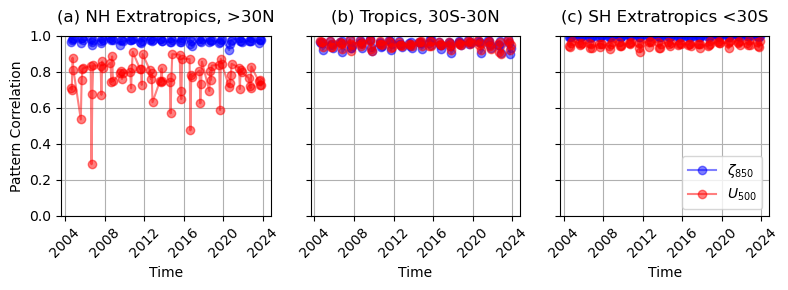

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

lats_list = [slice(30,90), slice(-30,30), slice(-90,30)]  # Replace with actual latitude values
title_list = ["(a) NH Extratropics, >30N", "(b) Tropics, 30S-30N", "(c) SH Extratropics <30S"]

for i in range(len(axes)):
    ax = axes[i]
    lats = lats_list[i]
    title = title_list[i]

    times = factual_mean.time.values
    pattern_corrs_gph = []
    pattern_corrs_u = []
    
    for time in times:
        data_f_mo = factual_mean.sel(time=time,level=500).sel(latitude=lats)
        data_era5_mo = era5_mean.sel(time=time,level=500).sel(latitude=lats)
    
        corr_gph = get_pattern_corr(data_f_mo["geopotential"], data_era5_mo["geopotential"])
        pattern_corrs_gph.append(corr_gph)
    
        corr_u = get_pattern_corr(data_f_mo["u_component_of_wind"], data_era5_mo["u_component_of_wind"])
        pattern_corrs_u.append(corr_u)
    
    ax.plot(times, pattern_corrs_gph, marker='o', linestyle='-', color='b', label=r"$\zeta_{850}$", alpha=.5)
    ax.plot(times, pattern_corrs_u, marker='o', linestyle='-', color='r', label=r"$U_{500}$", alpha=.5)
    ax.set_title(title,pad=10)
    if i==0:
        ax.set_ylabel('Pattern Correlation')
    if i==2:
        ax.legend(loc="lower right")
    ax.set_xlabel('Time')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)
    ax.set_ylim(0,1)

plt.tight_layout()
plt.savefig("./figs/SI_figure2.png",dpi=300)
plt.show()